In [33]:
# Base
import librosa # alternativa pyAudioAnalysis ali audioFlux
import numpy as np
import os
import h5py
import time
import datetime
from scipy import signal
import matplotlib.pyplot as plt

# Preprocessing, Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Keras, Classification
import keras
from keras import models
from keras import layers
from sklearn.svm import SVC
import tensorflow as tf
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.utils import to_categorical

# Parameters
genres = np.array('pop rock classical blues country disco metal jazz reggae hiphop'.split())
n_genres = len(genres) # 10 genres
n_genres_files = 100   # Files per genre, 1000 total
n_mfcc_coef = 10       # Experiment with no. of coeffs.
n_parts_sig = 2        # This should be set to 1-3 seconds, not only to two parts as it is now (2x14 seconds)!

In [34]:
def extract_features(y, sr, n_mfcc_coef, n_fft=512, hop_length=160, window=signal.windows.hamming(512), fmin=300, fmax=8000, verbose=False):
    vectors = [] 

    # Binary mask (True/False) representing if the signal crossed the x axis or not.
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=int(sr/4))
    vectors.append(zcr)

    # Estimated tempo (BPM) vector (multi-chanel signal -> 1 tempo per channel).
    tempo = librosa.feature.tempo(y=y, sr=sr)
    vectors.append(tempo)
    # Add more feature extractors!

    # MFCC
    # Can use Kapre (https://github.com/keunwoochoi/kapre) GPU
    # Not all parameters are provided!! Change!
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc_coef, n_fft=n_fft, hop_length=hop_length, window=window, fmin=fmin, fmax=fmax)

    for i in range(0, n_mfcc_coef):
        vectors.append(np.mean(mfcc[i]))

    # Flatten into one vector - feature vector
    flat = np.concatenate([x.ravel() for x in vectors])

    if verbose:
        print(f"Tempo: {tempo.shape}, ZCR: {zcr.shape}, MFCC: {mfcc.shape}, Flat: {flat.shape}")

    return flat

In [35]:
# Dataset - Will take some time to generate
data = []
data_labels = []

for i_genre in range(0, n_genres):
    print(f"genre: {genres[i_genre]}")
    for filename in os.listdir(f'/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/genres/{genres[i_genre]}'):
        fn = f'/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/genres/{genres[i_genre]}/{filename}'
        
        # There is one problematic file - format problem (can try ffmpeg decoder) - pip install ffmpeg-python
        try:
            # Load file (sig-signal; sr-sampling rate)
            sig, sr = librosa.load(fn, mono=True, duration=28) # Load 28 seconds of the file

            # Split signals into smaller chunks
            for y in np.split(sig, n_parts_sig): # Not only into two - more (per seconds)!
                # Features - Data

                ef = extract_features(y, sr, n_mfcc_coef, verbose=False)

                if len(ef) < 68: # 68 features - this should be the same for all files, otherwise there is a problem with the feature extraction
                    print(f"File: {fn}, features: {len(ef)}")
                else:
                    data.append(ef)

                # Genre - Label
                data_labels.append(i_genre)
        except:
            pass     

# Covert to numpy arrays
data = np.array(data)
data_labels = np.array(data_labels)

print("Data size:", np.shape(data))
print("Data labels size:", np.shape(data_labels))

# Save to h5 file
hf = h5py.File('dataset.h5', 'w')
hf.create_dataset('data', data=data)
hf.create_dataset('data_labels', data=data_labels)
hf.close()

genre: pop
genre: rock
genre: classical
genre: blues
genre: country
genre: disco
genre: metal
genre: jazz


/tmp/ipykernel_48267/3111802209.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(fn, mono=True, duration=28) # Load 28 seconds of the file
/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


genre: reggae
genre: hiphop
Data size: (1998, 68)
Data labels size: (1998,)


In [36]:
# Load dataset from h5 file
hf = h5py.File('dataset.h5', 'r')

data = hf.get('data')
data = np.array(data)

data_labels = hf.get('data_labels')
data_labels = np.array(data_labels)

print('Data size:', np.shape(data))
print('Data_labels size:', np.shape(data_labels))

hf.close()

Data size: (1998, 68)
Data_labels size: (1998,)


Train: (1198,)
Test: (400,)
Val: (400,)


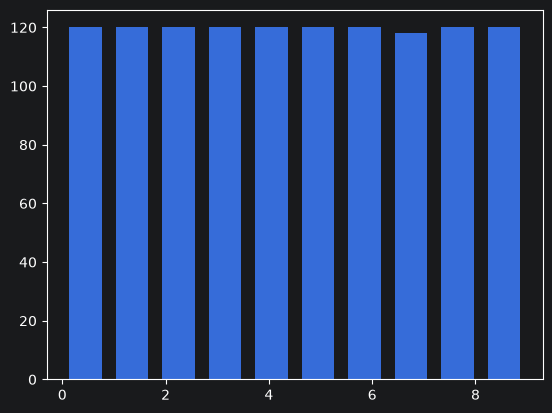

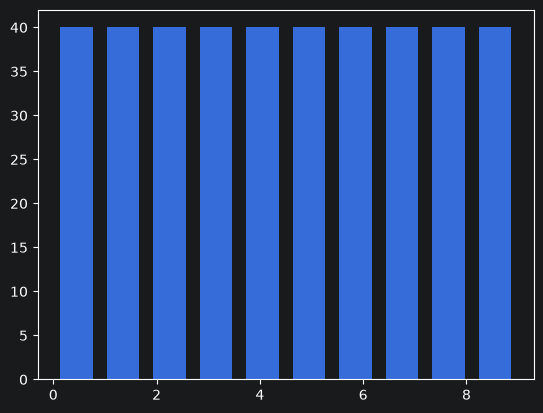

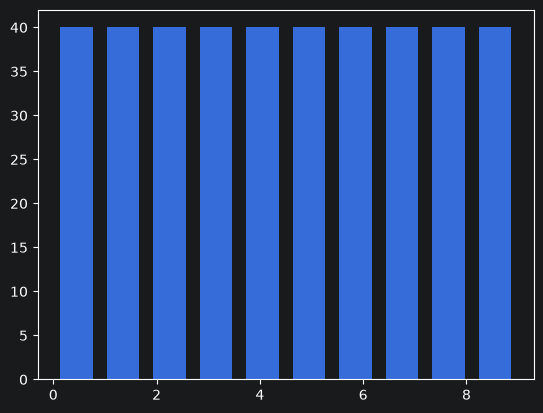

In [37]:
# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(np.array(data, dtype = float))

# Split into test and train
# Why stratify=data_labels?
# Check the histograms, try removing stratify
X_train, X_test, y_train, y_test = train_test_split(X, data_labels, test_size=0.2, stratify=data_labels)

# Split into train and valid
# Why stratify=y_train?
# Check the histograms, try removing stratify
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train)

# Sizes
print('Train:', np.shape(y_train))
print('Test:', np.shape(y_test))
print('Val:', np.shape(y_val))

# The truth is — there is no optimal split percentage
# train 80%; valid 10%; test 10%
# train 70%; valid 15%; test 15%
# tarin 60%; valid 20%; test 20%

plt.hist(y_train, bins=n_genres, rwidth=0.7)
plt.show()
plt.hist(y_test, bins=n_genres, rwidth=0.7)
plt.show()
plt.hist(y_val, bins=n_genres, rwidth=0.7)
plt.show()

In [38]:
# NN
model = models.Sequential()
model.add(layers.Input((X_train.shape[1],)))
model.add(layers.Dense(16, activation='relu')) # Input layer - number of features
# Fix the model - add extra layers, change the number of neurons, etc...
model.add(layers.Dense(n_genres, activation='softmax')) # Output layer - 10 genres

opt = keras.optimizers.Adam(learning_rate = 0.001) # Maybe a bit too high? Adam is used to optimize updating the weights
loss = tf.keras.losses.SparseCategoricalCrossentropy() # Computes the crossentropy loss between the labels and predictions
metr = keras.metrics.SparseCategoricalAccuracy() # Calculates how often predictions match integer labels
model.compile(optimizer=opt, loss=loss, metrics=[metr])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │         1,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274 (4.98 KB)

 Trainable params: 1,274 (4.98 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Stopping criterion to avoid overfitting
# patience: Number of epochs with no improvement after which training will be stopped.
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# Save best weights
model_checkpoint = ModelCheckpoint("mlp.weights.h5", save_best_only=True, save_weights_only=True)

# Train
t_epochs = 15 # Needs to be tuned
b_size = 8 # Needs to be tuned as well - What is batch_size?
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=t_epochs, batch_size=b_size, callbacks=[early_stopping, model_checkpoint])

# Load best weights
model.load_weights("mlp.weights.h5")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4242 - sparse_categorical_accuracy: 0.1519 - val_loss: 2.2676 - val_sparse_categorical_accuracy: 0.1925
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.1200 - sparse_categorical_accuracy: 0.2696 - val_loss: 2.1089 - val_sparse_categorical_accuracy: 0.2475
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.9548 - sparse_categorical_accuracy: 0.3347 - val_loss: 2.0102 - val_sparse_categorical_accuracy: 0.2900
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8325 - sparse_categorical_accuracy: 0.3881 - val_loss: 1.9390 - val_sparse_categorical_accuracy: 0.3300
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7338 - sparse_categorical_accuracy: 0.4149 - val_loss: 1.8821 - val_sparse_categorical_accuracy: 0.3525
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6526 - sparse_categorical_accuracy: 0.4382 - val_loss: 1.8348 - val_sparse_categorical_accuracy: 0.3775
Epoc

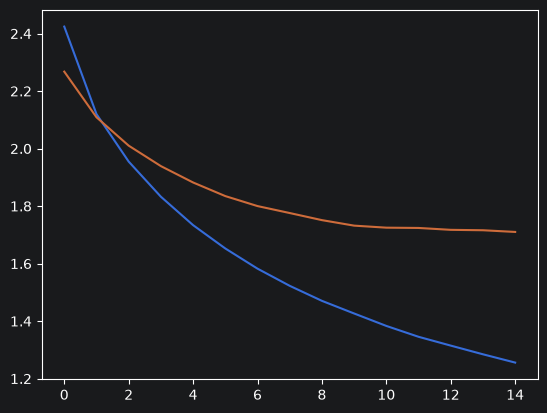

In [40]:
# Lets observe the loss metric on both the training (blue) and validation (orange) set
# What do we noice?
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

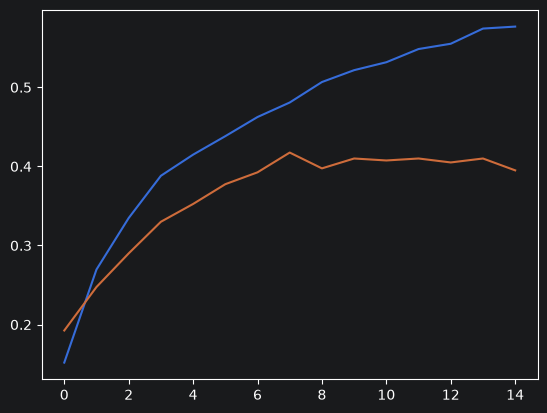

In [41]:
plt.figure()
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.show()

In [42]:
# Now to evaluate our model on train and test data

# Train NN
test_loss, test_acc = model.evaluate(X_train, y_train, verbose=0)
print('Acc train NN: %.3f' % test_acc)

# Test NN
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('Acc test NN: %.3f' % test_acc)

Acc train NN: 0.598
Acc test NN: 0.412


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


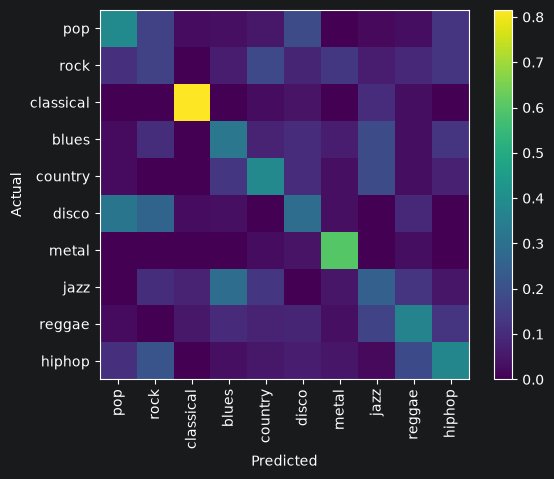

In [43]:
# Test NN
# Predictions for additional analysis
predictions = model.predict(X_test)

# Confusion matrix
predicted_labels = np.argmax(predictions, axis=1)
conf = confusion_matrix(y_test, predicted_labels, normalize="pred") # Normalize pred! Explain why?

# Visualise confusion matrix
plt.figure()
plt.imshow(conf)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.yticks(np.arange(n_genres), genres)
plt.xticks(np.arange(n_genres), genres, rotation='vertical')
plt.colorbar()
plt.show()